### Q1
1.   Checking the amount of a bank check that is to be cashed.
2.   Phone number recognition from a contact form.
3. Checking multiple choice homework that is defined by numbers.

### Q2


1.   The training loss starts as a higher number compared to the validation loss, similarly the training accuracy also starts lower than the validation accuracy. This is because the training loss is evaluated during the forward pass of the network and the validation loss is evaluated afterwards. Therefore the validation loss is one step behind the training loss calculation, leading to lower validation losses.
2.   The training loss reaches lower values than the validation loss eventually. If this difference would be severe, it could indicate overfitting to the training set.
3. While the training loss decreases with more epochs, the validation loss does not decrease as nearly as significantly. This is another sign of overfitting.
4. The volatility of the validation set is higher than that of the training set. This is likely because (1) the validation set is 4 times smaller than the training set and (2) because the model's update is based on the training set, not on the validation set.
5. The high final validation accuracy (>92%) shows the model generalises well to our validation set beyond our training set. We therefore estimate that our model will also generalise well to an unseen test set.


### Q3

For all scenarios, we generally think that this accuracy is too low since a human will have a higher accuracy in this task. However, if you are in a situation where there is a strict time constraint for your digitalisation and this level of error is allowed then it is okay. For our mentioned purposes from Q1:


1.   **Bank Check amount**: To avoid fraud we would recommend to use a human for this task.
2.   **Phone number recognition**: Depending on the importance of getting the right number and the number of forms that need to be checked. This could be okay if the cost of errors outweighs the cost of manual checking.
3. **Homework checking**: Again, this depends on the importance of the homework. For ungraded work this is fine, for graded work we recommend a teacher checking the grades and for exams we do not recommend using this model.

EDIT: Important for phone numbers with 10 numbers and long quizes with many answers, the chance of errors is multiplied each use. I.e. for a phone number there is a 43% chance of getting the entire number correct. We therefore do not recommend using it for this purpose. The same holds for a lot of bank checks and homework.

### Q4

The internal operations by the nodes in the network are also linear. By using linear activation functions, we can only get outputs that are linear with respect to the input. A non-linear activation function allows the model to learn non-linear patterns in the data.

Therefore the model itself is also linear.


### Q5

Comparing this non-linear model to the previous linear model:

1. The training accuracy of the new model (98%) is much higher compared to the linear model(92%). A similar trend is observed for the valdiation accuracy, thus the non-linear model is expected to have greater generalisation beyond the training data set.
2. The validation loss for the non-linear model is much more stable and it seems to actually converge instead bouncing up and down.
3. If an early stopping algorithm was to be used based on the validation loss, training could be stopped after just a few (~4) epochs because the validation loss stops decreasing. Continuing training can lead to overfitting.
4. There is a larger difference between the training and validation loss at the end of training. Which is also why an early stopping could be beneficial.

EDIT:

5. We observe that the space between the training and validation losses grows as training progresses, indicating overfitting on the training data.
6. The curves for this non-linear model are exponential instead of the more randomly volatile curves observed for the linear model.



### Q6

Similarely to the previous fully-connected network, this greatly depends on the level of error you can afford. If the task is delicate then you would perhaps prefer a human classfier over an automated one. However, given the test accuracy of 98.6% it is possible that this algorithm outperforms some humans in this task.

This means that this algorithm has a phone number correct 0.986^10 = 86.8% of the time. So for this certain task would it be insuficient

### Q7

* (a) Training is slower because the model and dataset is too small. With the current size, determining what parameters to 'turn off' is more expensive than simply updating all parameters.

* (b) The largest immediate benefit of the dropout is the reducing effect of overfitting. The space between the training and validation losses/accuracies is (almost entirely) removed meaning the model performs just as well on the validation data as on the training data after ~6 epochs.

* (c) In conclusion, the less complex model with the suggested dropout implemented generalises better than the non-dropout model due by reducing overfitting. You can see how the accuracy of the validation and training data do not grow apart as fast, meaning the model is not over-fitting as much. This is also reflected in the test accuracy of the models which increases from 98.6% to 98.7%. A small increase but an increase nonetheless.



---


In [1]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"shape of x_train: {x_train.shape}")

# reshape from 28,28 to one 784 dimension
x_train_flat = np.reshape(x_train, (60000, 784), copy=True)
x_test_flat = np.reshape(x_test, (10000, 784), copy=True)
print(f"shape of x_train_flat: {x_train_flat.shape}")

# normalise to values between 0-1 instead of 0-255
x_train_flat = x_train_flat / 255
x_test_flat = x_test_flat / 255


# recategorise values to numerical values 0-9
print(y_train[0:3])
print(np.unique(y_train))

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(y_train[0:3])
print(np.unique(y_train))


# Reshape the training and test data to right shapes and normalise
x_train_conv = np.reshape(x_train, (60000, 28, 28, 1), copy=True)
x_test_conv = np.reshape(x_test, (10000, 28, 28, 1), copy=True)

x_train_conv = x_train_conv / 255
x_test_conv = x_test_conv / 255

shape of x_train: (60000, 28, 28)
shape of x_train_flat: (60000, 784)
[5 0 4]
[0 1 2 3 4 5 6 7 8 9]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
[0. 1.]


### Q8

Below is our convolutional operation function. We have not managed to remove the for loops, but we did manage a way to only loop over the filter and not the input image.

In [2]:
def conv_operation(filter, input_layer, padding='valid'):
    """
    Only handle cases where the input layer contains 1 or multiple stacked 2D images.
    The filter is always the same 3d filter applied to all images in the input layer.

    filter: 3D array of shape (fh, fw, fd)
    input_layer: 2D array of shape (H, W) for a single image, or
                 3D array of shape (H, W, N) for a stack of N images

    returns: 3D array of shape (out_h, out_w, N) if input was a stack
    """
    # remember if we started with a single 2D image    
    single_image = len(np.shape(input_layer)) == 2

    if single_image:
        # make sure the rest of the function only has to deal with the 3D case
        H, W = np.shape(input_layer)
        input_layer = np.reshape(input_layer, (H, W, 1))

    H, W, N = np.shape(input_layer)
    fh, fw = np.shape(filter)

    if padding == 'same':
        pad_h = fh - 1
        pad_w = fw - 1
        pad_top = int(pad_h / 2)
        pad_bottom = pad_h - pad_top
        pad_left = int(pad_w / 2)
        pad_right = pad_w - pad_left

        padded = np.zeros((H + pad_h, W + pad_w, N))
        padded[pad_top:pad_top + H, pad_left:pad_left + W, :] = input_layer
        input_layer = padded
        H, W, N = np.shape(input_layer)

    out_h = H - fh + 1
    out_w = W - fw + 1

    output = np.zeros((out_h, out_w, N))

    # loop over filter size and apply the filter to the input layer
    for i in range(fh):
        for j in range(fw):
            output += filter[i, j] * input_layer[i:i + out_h, j:j + out_w, :]


    if single_image:
        output = np.reshape(output, (out_h, out_w))

    return output

In [3]:
# test: 4x4 image, 2x2 filter, single 2D input
test_img = np.array([[1, 2, 3, 4],
                      [5, 6, 7, 8],
                      [9, 10, 11, 12],
                      [13, 14, 15, 16]])
test_filter = np.array([[1, 0],
                         [0, -1]])

result = conv_operation(test_filter, test_img)
print(result.shape)  # expect (3, 3)
print(result)

(3, 3)
[[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]


input stack shape: (28, 28, 3)
output shape: (28, 28, 3)


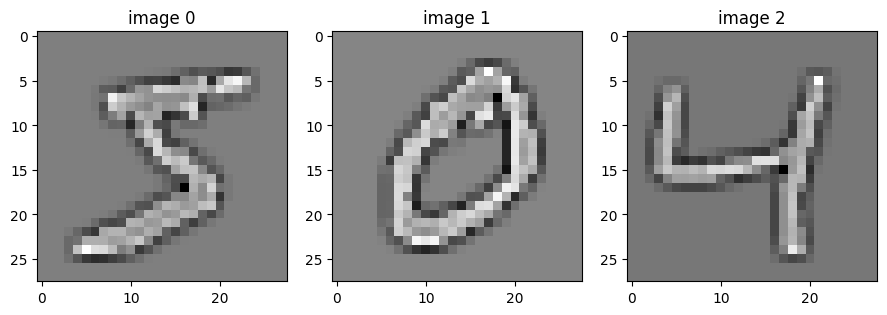

In [4]:
# test on 3 MNIST images
n_images = 3
stack = np.transpose(x_train[:n_images], (1, 2, 0))
print('input stack shape:', stack.shape)

# Filter to find edges:
edge_filter = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])


# Filter to find horizontal edges:
horizontal_edges = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
])

feature_maps = conv_operation(edge_filter, stack, padding='same')
print('output shape:', feature_maps.shape)

fig, axes = plt.subplots(1, n_images, figsize=(9, 3))
for k in range(n_images):
    axes[k].imshow(feature_maps[:, :, k], cmap='gray')
    axes[k].set_title(f'image {k}')
plt.tight_layout()
plt.show()

---

### Q9

Here we implement the ReLu function.

(28, 28, 3)


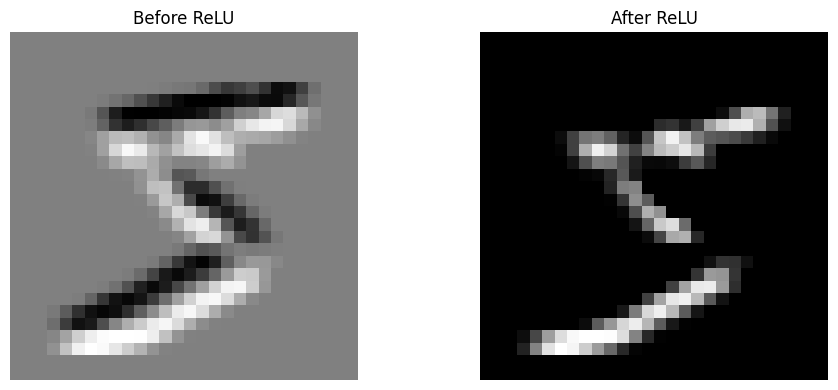

In [ ]:
def relu(feature_map):
    return np.maximum(feature_map, 0)

result = conv_operation(horizontal_edges, stack, padding='same')

print(result.shape)  # expect (28, 28, 3)

image = result[:, :, 0]  # take the first image in the stack

relu_horizontal = relu(image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Before ReLU')
axes[1].imshow(relu_horizontal, cmap='gray')
axes[1].set_title('After ReLU')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

---

### Q10

In [22]:
def maxpooling(feature_map, pool_size=2, stride=2):
    """
    params:
    - feature_map: 3D array representing the feature map to be pooled.
    - pool_size: size of the pooling window (default is 2).
    - stride: step size for moving the pooling window (default is 2).
    - in_d: depth of the input feature map.

    output:
    - pooled_feature_map: 3D array after applying max pooling.
    """
    in_h, in_w, in_d = feature_map.shape
    out_h = (in_h - pool_size) // stride + 1
    out_w = (in_w - pool_size) // stride + 1
    out_d = in_d

    pooled_feature_map = np.zeros((out_h, out_w, out_d))

    for i in range(out_h):
        for j in range(out_w):
            for d in range(out_d):
                h_start = i * stride
                h_end = h_start + pool_size
                w_start = j * stride
                w_end = w_start + pool_size

                pooled_feature_map[i, j, d] = np.max(feature_map[h_start:h_end, w_start:w_end, d])

    return pooled_feature_map

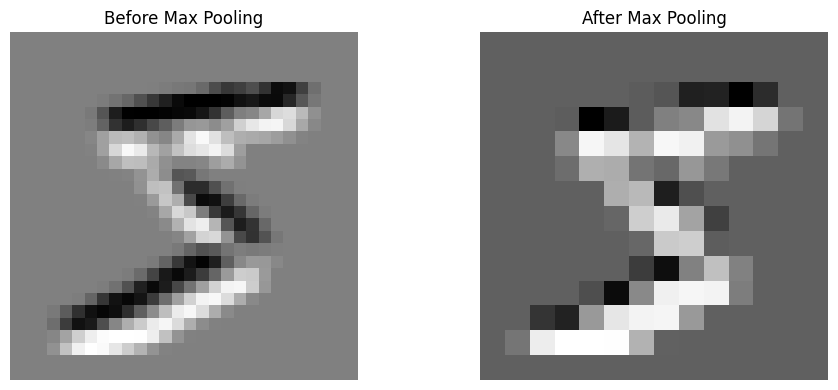

In [23]:
pooled = maxpooling(result, pool_size=2, stride=2)



fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Before Max Pooling')
axes[1].imshow(pooled[:,:,0], cmap='gray')
axes[1].set_title('After Max Pooling')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

---

### Q11

In [24]:
def normalisation(feature_map):
  output = np.zeros(feature_map.shape)
  for i in range(feature_map.shape[2]):
    mean = np.mean(feature_map[:,:,i])
    std = np.std(feature_map[:,:,i])

    if std == 0:
        return feature_map[:,:,i] - mean  # Avoid division by zero

    output[:,:,i] = (feature_map[:,:,i] - mean) / std
  
  return output

In [ ]:
normalised_layer = normalisation(pooled)

print(f"mean: {np.mean(normalised_layer)}, std: {np.std(normalised_layer)}")

mean: 0.0, std: 1.0


---

### Q12

In [30]:
def connected_layer(feature_map, weights, output_size):
  """
  Input the activations of every node in a stack of feature maps and a set of weights linking every input node to every output node.
  """
  height, width, depth = feature_map.shape[0], feature_map.shape[1], feature_map.shape[2]
  output = np.zeros(output_size)


  weight_index = 0
  for row in range(height):
    for col in range(width):
      for layer in range(depth):
        output += feature_map[row, col, layer] * weights[weight_index:weight_index+output_size]
        weight_index += output_size

  return output

In [32]:
# connected layer testing
output_size = 10
weights = np.random.rand(normalised_layer.shape[0] * normalised_layer.shape[1] * normalised_layer.shape[2]*output_size)

prediction = connected_layer(normalised_layer, weights, output_size)
prediction

array([ -8.85008781,  -7.24078227,  -5.66927203,  13.65813848,
        -8.61900029, -12.58822223,  -5.29794018,  -0.73952167,
        -0.80829685,   4.89279153])

---

### Q13

In [33]:
def softmax_layer(feature_map):

  output_layer = []

  sum = np.sum(np.exp(feature_map))

  for value in feature_map:
    p = np.exp(value) / sum
    output_layer.append(float(p))

  return output_layer

In [ ]:
probability_image = softmax_layer(prediction)

print(probability_image)

prediction_index = np.argmax(probability_image)
print(f"The image is a {prediction_index}")



# because of random weights this prediction will likely not be correct

[1.6777733287796898e-10, 8.387756242605767e-10, 4.037792754662226e-09, 0.9998428853224146, 2.1139432366345316e-10, 3.992842089462442e-12, 5.853443065198534e-09, 5.586083266743992e-07, 5.214812785367608e-07, 0.00015602347480432604]
The image is a 3
